# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Social Media & Mental Health** (Kaggle), berisi 8.000 rekaman sintetis yang merepresentasikan perilaku pengguna media sosial serta dampaknya terhadap kesehatan mental.

**Fitur utama:**
- `User_ID`, `Age`, `Gender`, `User_Archetype`, `Primary_Platform`
- `Daily_Screen_Time_Hours`, `Dominant_Content_Type`, `Activity_Type`
- `Late_Night_Usage`, `Social_Comparison_Trigger`, `Sleep_Duration_Hours`
- `GAD_7_Score` (Anxiety 0–21), `GAD_7_Severity`
- `PHQ_9_Score` (Depression 0–27), `PHQ_9_Severity` ← **Target prediksi**

**Tujuan:** Memprediksi `PHQ_9_Severity` (tingkat depresi) berdasarkan pola penggunaan media sosial dan faktor perilaku.

# **2. Import Library**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print('Libraries imported successfully.')

Libraries imported successfully.


# **3. Memuat Dataset**

In [13]:
# Load dataset
df = pd.read_csv(r'C:\Users\along\OneDrive\Desktop\Membangun-Sistem-Machine-Learning\social_media_mental_health.csv')

print('Shape:', df.shape)
print('\nSample data:')
df.head()

Shape: (8000, 15)

Sample data:


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [14]:
# Cek kolom dan tipe data
print('Columns & dtypes:')
print(df.dtypes)
print('\nBasic info:')
df.info()

Columns & dtypes:
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage               int64
Social_Comparison_Trigger      int64
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Arc

# **4. Exploratory Data Analysis (EDA)**

## 4.1 Statistik Deskriptif

In [15]:
# Statistik deskriptif numerik
df.describe()

,Age,Daily_Screen_Time_Hours,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,PHQ_9_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.057875,4.277210,0.379375,0.103125,5.803237,7.354250,5.380125
std,1.117892,2.310486,0.485262,0.304141,1.344054,4.633108,4.816641
min,18.000000,0.500000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,18.000000,2.420000,0.000000,0.000000,4.800000,4.000000,1.000000
50%,19.000000,4.270000,0.000000,0.000000,5.800000,7.000000,5.000000
75%,20.000000,6.050000,1.000000,0.000000,6.800000,11.000000,9.000000
max,22.000000,11.310000,1.000000,1.000000,11.600000,21.000000,23.000000


In [16]:
# Statistik deskriptif kolom kategorikal
cat_cols = df.select_dtypes(include='object').columns
print('Categorical columns:', list(cat_cols))
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())

Categorical columns: ['User_ID', 'Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type', 'Activity_Type', 'GAD_7_Severity', 'PHQ_9_Severity']

User_ID:
User_ID
U-b23639d2    1
U-fc4c885f    1
U-51667ef8    1
U-be44642c    1
U-e22338c5    1
             ..
U-93ae548b    1
U-7a9cbff4    1
U-04ec3425    1
U-da3d4e7c    1
U-2d834d22    1
Name: count, Length: 8000, dtype: int64

Gender:
Gender
Female    4028
Male      3972
Name: count, dtype: int64

User_Archetype:
User_Archetype
Hyper-Connected       2068
Digital Minimalist    2030
Average User          1993
Passive Scroller      1909
Name: count, dtype: int64

Primary_Platform:
Primary_Platform
TikTok       1185
Instagram    1165
Twitter/X    1147
YouTube      1134
LinkedIn     1132
Snapchat     1124
Facebook     1113
Name: count, dtype: int64

Dominant_Content_Type:
Dominant_Content_Type
Lifestyle/Fashion       1387
Entertainment/Comedy    1359
Self-Help/Motivation    1347
Educational/Tech        1303
News/Politics      

## 4.2 Missing Values & Duplikat

In [17]:
# Cek missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# Cek duplikat
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
User_ID                      0
Age                          0
Gender                       0
User_Archetype               0
Primary_Platform             0
Daily_Screen_Time_Hours      0
Dominant_Content_Type        0
Activity_Type                0
Late_Night_Usage             0
Social_Comparison_Trigger    0
Sleep_Duration_Hours         0
GAD_7_Score                  0
GAD_7_Severity               0
PHQ_9_Score                  0
PHQ_9_Severity               0
dtype: int64

Total missing: 0

Duplicate rows: 0


## 4.3 Distribusi Target (PHQ_9_Severity)

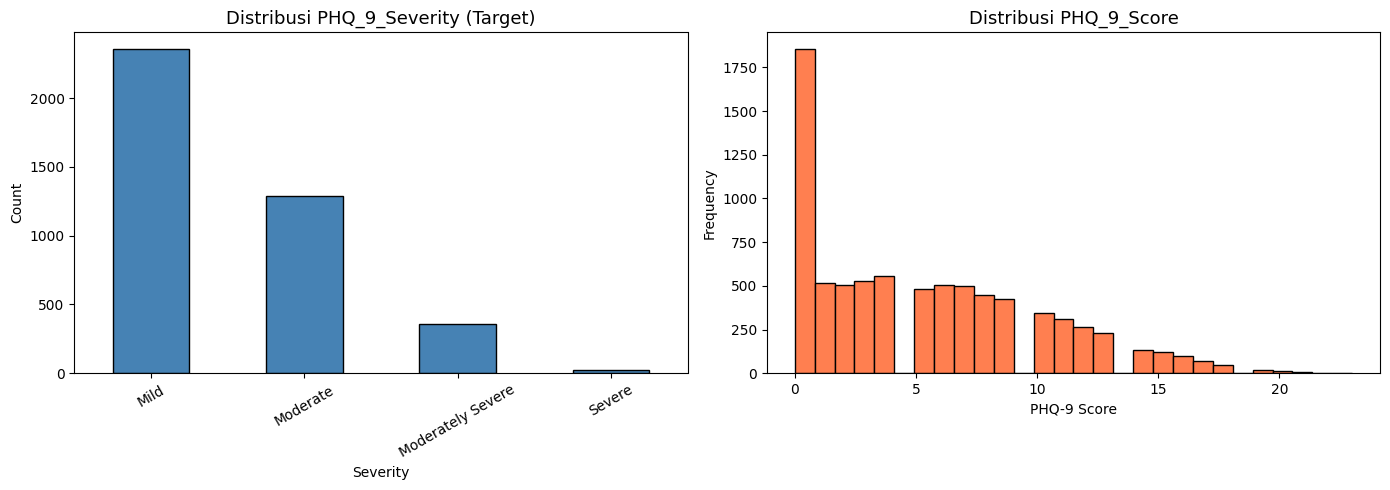

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi PHQ_9_Severity
order = ['None', 'Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe']
existing_order = [x for x in order if x in df['PHQ_9_Severity'].unique()]
df['PHQ_9_Severity'].value_counts().reindex(existing_order).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribusi PHQ_9_Severity (Target)', fontsize=13)
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Distribusi PHQ_9_Score
axes[1].hist(df['PHQ_9_Score'], bins=28, color='coral', edgecolor='black')
axes[1].set_title('Distribusi PHQ_9_Score', fontsize=13)
axes[1].set_xlabel('PHQ-9 Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 4.4 Distribusi Fitur Numerik

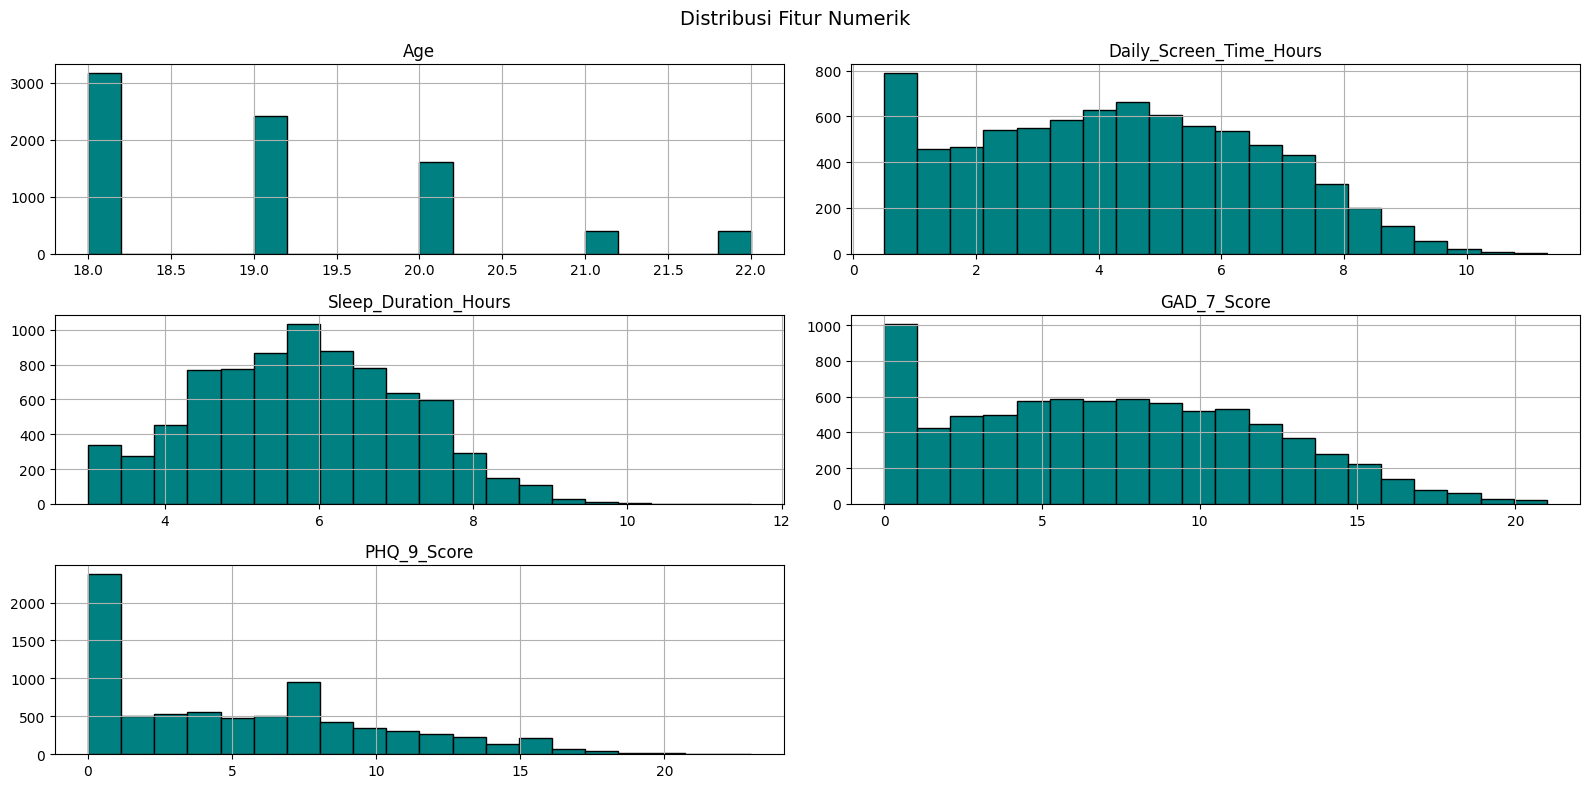

In [19]:
num_cols = ['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours', 'GAD_7_Score', 'PHQ_9_Score']
df[num_cols].hist(bins=20, figsize=(16, 8), color='teal', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

## 4.5 Korelasi Antar Fitur Numerik

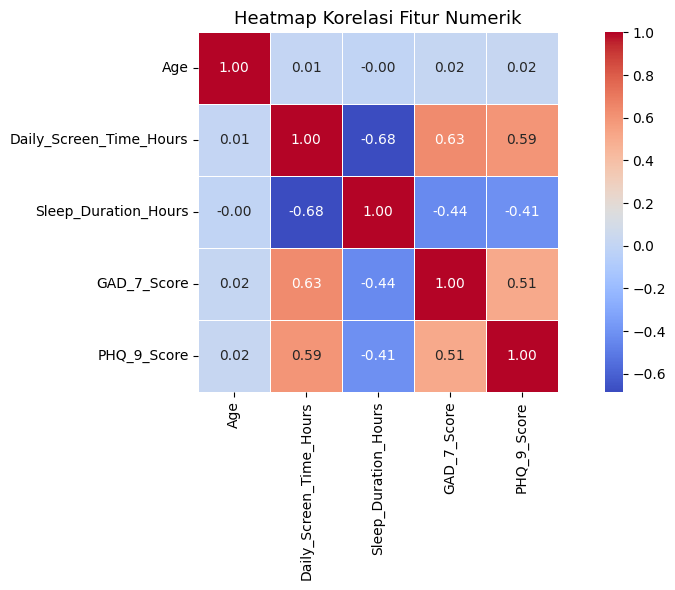

In [20]:
plt.figure(figsize=(10, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.show()

## 4.6 Analisis Gender vs PHQ-9

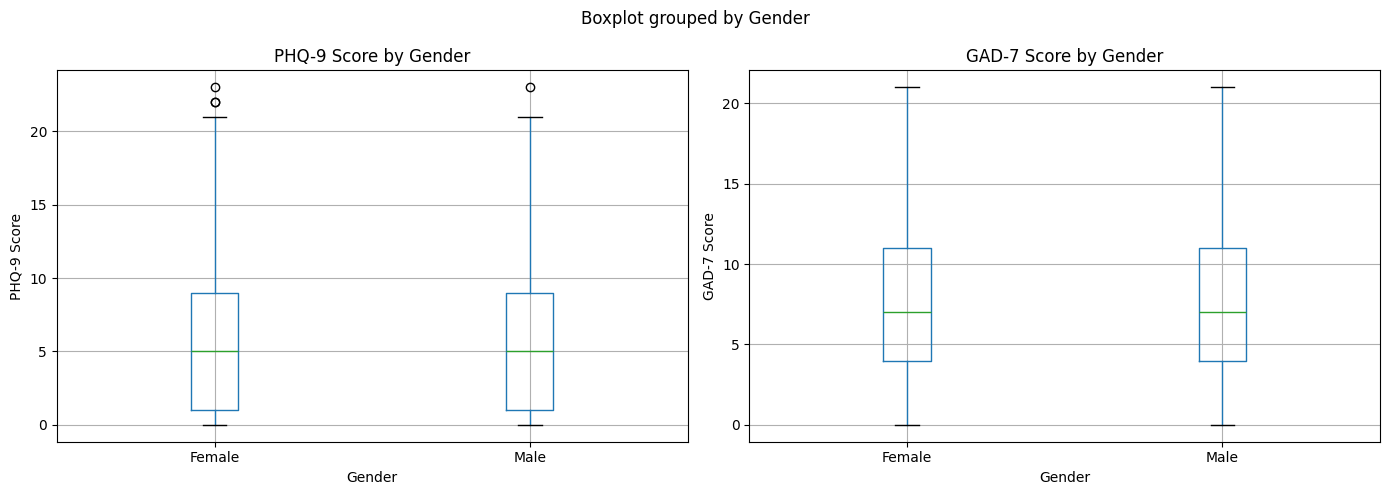

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot PHQ_9_Score per Gender
df.boxplot(column='PHQ_9_Score', by='Gender', ax=axes[0])
axes[0].set_title('PHQ-9 Score by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('PHQ-9 Score')

# Boxplot GAD_7_Score per Gender
df.boxplot(column='GAD_7_Score', by='Gender', ax=axes[1])
axes[1].set_title('GAD-7 Score by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('GAD-7 Score')

plt.tight_layout()
plt.show()

## 4.7 Screen Time vs PHQ-9 Score

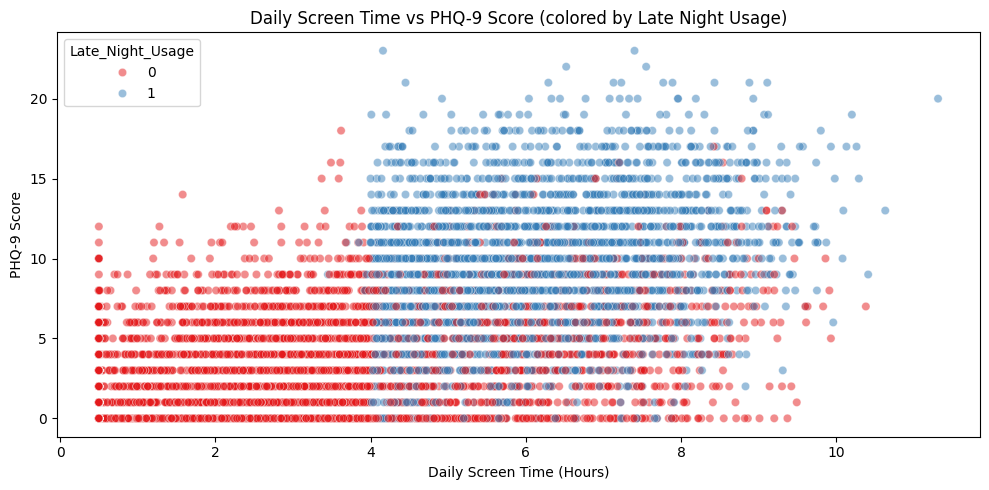

In [22]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, x='Daily_Screen_Time_Hours', y='PHQ_9_Score',
    hue='Late_Night_Usage', alpha=0.5, palette='Set1'
)
plt.title('Daily Screen Time vs PHQ-9 Score (colored by Late Night Usage)', fontsize=12)
plt.xlabel('Daily Screen Time (Hours)')
plt.ylabel('PHQ-9 Score')
plt.tight_layout()
plt.show()

## 4.8 Platform vs PHQ-9 Severity

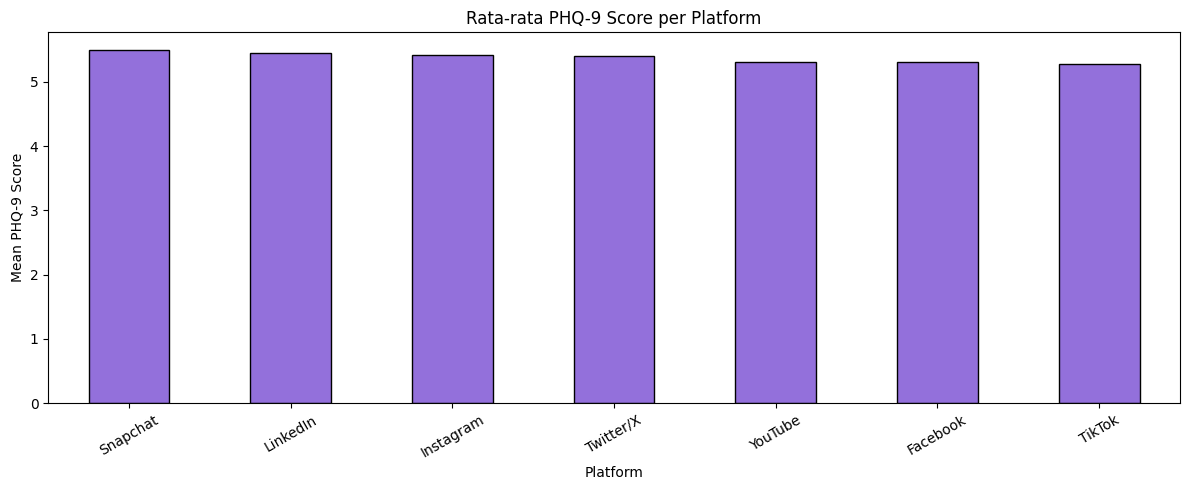

In [23]:
plt.figure(figsize=(12, 5))
platform_phq = df.groupby('Primary_Platform')['PHQ_9_Score'].mean().sort_values(ascending=False)
platform_phq.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Rata-rata PHQ-9 Score per Platform', fontsize=12)
plt.xlabel('Platform')
plt.ylabel('Mean PHQ-9 Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

## 5.1 Hapus Kolom Tidak Relevan

In [24]:
# Hapus User_ID (identifier, tidak informatif untuk model)
# Hapus PHQ_9_Score & GAD_7_Score karena sudah direpresentasikan oleh severity (menghindari data leakage)
df_clean = df.drop(columns=['User_ID', 'PHQ_9_Score', 'GAD_7_Score'])

print('Shape setelah drop kolom:', df_clean.shape)
print('Kolom tersisa:', list(df_clean.columns))

Shape setelah drop kolom: (8000, 12)
Kolom tersisa: ['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours', 'GAD_7_Severity', 'PHQ_9_Severity']


## 5.2 Tangani Missing Values

In [25]:
# Cek ulang missing values
print('Missing values:')
print(df_clean.isnull().sum())

# Isi missing values numerik dengan median, kategorikal dengan modus
for col in df_clean.select_dtypes(include=np.number).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print('\nMissing values after handling:', df_clean.isnull().sum().sum())

Missing values:
Age                          0
Gender                       0
User_Archetype               0
Primary_Platform             0
Daily_Screen_Time_Hours      0
Dominant_Content_Type        0
Activity_Type                0
Late_Night_Usage             0
Social_Comparison_Trigger    0
Sleep_Duration_Hours         0
GAD_7_Severity               0
PHQ_9_Severity               0
dtype: int64

Missing values after handling: 0


## 5.3 Hapus Duplikat

In [26]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Rows removed (duplicates): {before - after}')
print(f'Shape setelah deduplikasi: {df_clean.shape}')

Rows removed (duplicates): 9
Shape setelah deduplikasi: (7991, 12)


## 5.4 Encoding Kolom Kategorikal

In [27]:
# Label Encoding untuk kolom kategorikal (termasuk target)
le = LabelEncoder()
cat_cols_to_encode = df_clean.select_dtypes(include='object').columns.tolist()
print('Kolom yang di-encode:', cat_cols_to_encode)

df_encoded = df_clean.copy()
label_mappings = {}

for col in cat_cols_to_encode:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('\nMapping PHQ_9_Severity:')
print(label_mappings.get('PHQ_9_Severity', 'N/A'))

df_encoded.head()

Kolom yang di-encode: ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type', 'Activity_Type', 'GAD_7_Severity', 'PHQ_9_Severity']

Mapping PHQ_9_Severity:
{'Mild': 0, 'Moderate': 1, 'Moderately Severe': 2, 'None-Minimal': 3, 'Severe': 4}


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Severity,PHQ_9_Severity
0,18,1,2,5,8.50,2,0,0,0,3.9,0,0
1,20,1,1,4,0.50,2,0,0,0,5.5,1,0
2,18,0,1,3,0.91,2,0,0,0,8.9,1,3
3,18,0,2,3,7.43,2,0,1,0,6.2,2,3
4,18,1,2,2,4.94,1,0,1,0,5.3,2,1


## 5.5 Deteksi & Tangani Outlier (IQR)

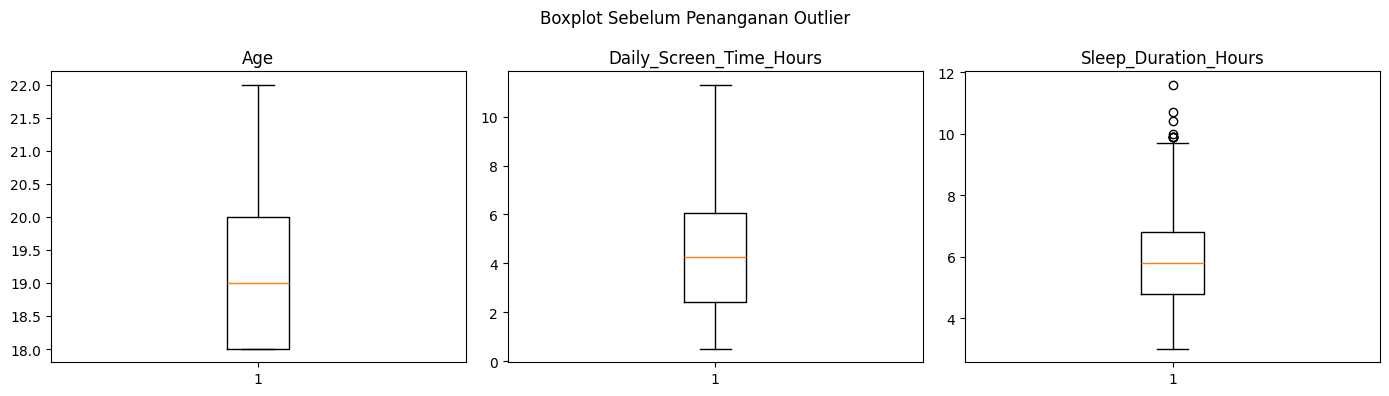

Outlier ditangani dengan clipping IQR.
Shape: (7991, 12)


In [28]:
# Visualisasi outlier sebelum penanganan
num_features = ['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']
fig, axes = plt.subplots(1, len(num_features), figsize=(14, 4))
for i, col in enumerate(num_features):
    axes[i].boxplot(df_encoded[col])
    axes[i].set_title(col)
plt.suptitle('Boxplot Sebelum Penanganan Outlier')
plt.tight_layout()
plt.show()

# Clipping outlier dengan batas IQR
df_no_outlier = df_encoded.copy()
for col in num_features:
    Q1 = df_no_outlier[col].quantile(0.25)
    Q3 = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_no_outlier[col] = df_no_outlier[col].clip(lower, upper)

print('Outlier ditangani dengan clipping IQR.')
print('Shape:', df_no_outlier.shape)

## 5.6 Pisahkan Fitur & Target, Lalu Normalisasi

In [29]:
# Pisahkan X dan y
X = df_no_outlier.drop(columns=['PHQ_9_Severity'])
y = df_no_outlier['PHQ_9_Severity']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target distribution:')
print(y.value_counts())

X shape: (7991, 11)
y shape: (7991,)
Target distribution:
PHQ_9_Severity
3    3957
0    2360
1    1291
2     356
4      27
Name: count, dtype: int64


In [30]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

# Normalisasi fitur numerik
scaler = StandardScaler()
num_cols_to_scale = ['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print('Normalisasi selesai.')
X_train.head()

Train size: (6392, 11), Test size: (1599, 11)
Normalisasi selesai.


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Severity
6540,-0.046536,1,2,5,0.909001,2,0,0,0,-0.371654,0
6209,-0.942492,0,2,2,2.270868,3,0,1,0,-1.863308,2
7906,-0.942492,0,2,6,1.494517,5,0,1,0,-2.087056,0
2773,0.849420,1,0,0,-0.227334,1,0,0,0,0.075843,1
2840,-0.046536,0,2,6,0.943698,1,0,0,0,0.150426,1


## 5.7 Simpan Dataset Preprocessing

In [31]:
import os
os.makedirs('social_media_mental_health_preprocessing', exist_ok=True)

# Gabungkan kembali train dan test untuk disimpan
df_train = pd.concat([X_train, y_train], axis=1)
df_test  = pd.concat([X_test,  y_test],  axis=1)

df_train.to_csv('social_media_mental_health_preprocessing/train.csv', index=False)
df_test.to_csv( 'social_media_mental_health_preprocessing/test.csv',  index=False)

print('Dataset preprocessing disimpan:')
print('  social_media_mental_health_preprocessing/train.csv')
print('  social_media_mental_health_preprocessing/test.csv')

Dataset preprocessing disimpan:
  social_media_mental_health_preprocessing/train.csv
  social_media_mental_health_preprocessing/test.csv


## 5.8 Verifikasi Data Siap Latih

In [32]:
print('=== Verifikasi Data Preprocessing ===')
print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'Missing values di X_train: {X_train.isnull().sum().sum()}')
print(f'Missing values di X_test : {X_test.isnull().sum().sum()}')
print('\nSample X_train:')
print(X_train.head(3))
print('\nDistribusi y_train:')
print(y_train.value_counts())

=== Verifikasi Data Preprocessing ===
X_train: (6392, 11)
X_test : (1599, 11)
Missing values di X_train: 0
Missing values di X_test : 0

Sample X_train:
           Age  Gender  User_Archetype  Primary_Platform  \
6540 -0.046536       1               2                 5   
6209 -0.942492       0               2                 2   
7906 -0.942492       0               2                 6   

      Daily_Screen_Time_Hours  Dominant_Content_Type  Activity_Type  \
6540                 0.909001                      2              0   
6209                 2.270868                      3              0   
7906                 1.494517                      5              0   

      Late_Night_Usage  Social_Comparison_Trigger  Sleep_Duration_Hours  \
6540                 0                          0             -0.371654   
6209                 1                          0             -1.863308   
7906                 1                          0             -2.087056   

      GAD_7_Severity